# Exploratory Data Analysis (EDA)
## Public Compliance Data Analysis - MBA Thesis

**Objective:** Explore the Gold layer datasets to understand:
- Data distributions and summary statistics
- Missing values and data quality
- Initial patterns and relationships
- Regional variations in compliance and socioeconomic indicators

In [39]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.analysis.data_loader import GoldDataLoader

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)


In [40]:
import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = (-99, 99)


## 1. Load Data

In [41]:
loader = GoldDataLoader(
    bucket_name="enok-mba-thesis-datalake",
    aws_profile="mba-thesis"
)

print("Available datasets:")
for dataset in loader.list_available_datasets():
    print(f"  • {dataset}")

2026-02-09 02:38:37,322 - INFO - Found credentials in shared credentials file: ~/.aws/credentials


Available datasets:
  • municipality_socioeconomic
  • state_summary
  • sanctions_summary
  • analysis_compliance


In [42]:
datasets = loader.load_all()

df_muni = datasets.get('municipality_socioeconomic')
df_state = datasets.get('state_summary')
df_sanctions = datasets.get('sanctions_summary')
df_analysis = datasets.get('analysis_compliance')

print(f"\n✅ Loaded {len(datasets)} datasets")

2026-02-09 02:38:37,730 - INFO - 📚 Loading all Gold layer datasets...
2026-02-09 02:38:37,731 - INFO - 📥 Loading municipality_socioeconomic from S3: gold/agg_municipality_socioeconomic/data.parquet
2026-02-09 02:38:39,325 - INFO - ✅ Loaded 5570 records, 18 columns
2026-02-09 02:38:39,327 - INFO - 📥 Loading state_summary from S3: gold/agg_state_summary/data.parquet
2026-02-09 02:38:39,502 - INFO - ✅ Loaded 27 records, 13 columns
2026-02-09 02:38:39,503 - INFO - 📥 Loading sanctions_summary from S3: gold/agg_sanctions_summary/data.parquet
2026-02-09 02:38:39,681 - INFO - ✅ Loaded 4 records, 8 columns
2026-02-09 02:38:39,682 - INFO - 📥 Loading analysis_compliance from S3: gold/analysis_compliance/data.parquet
2026-02-09 02:38:39,891 - INFO - ✅ Loaded 27 records, 21 columns
2026-02-09 02:38:39,892 - INFO - ✅ Loaded 4/4 datasets



✅ Loaded 4 datasets


## 2. Dataset Overview

In [43]:
print("=" * 80)
print("ANALYSIS COMPLIANCE DATASET")
print("=" * 80)
print(f"Shape: {df_analysis.shape}")
print(f"\nColumns: {list(df_analysis.columns)}")
print(f"\nData Types:\n{df_analysis.dtypes}")
print(f"\nMemory Usage: {df_analysis.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

ANALYSIS COMPLIANCE DATASET
Shape: (27, 21)

Columns: ['state_code', 'state_name', 'region_code', 'region_name', 'n_municipalities', 'population', 'avg_literacy_rate', 'avg_income', 'n_sanctions', 'n_sanctions_ceis', 'n_sanctions_cnep', 'n_sanctions_ceaf', 'n_sanctions_cepim', 'sanctions_per_100k', 'log_population', 'log_income', 'is_norte', 'is_nordeste', 'is_sudeste', 'is_sul', 'is_centro_oeste']

Data Types:
state_code                str
state_name                str
region_code               str
region_name               str
n_municipalities        Int64
population              Int64
avg_literacy_rate     float64
avg_income            float64
n_sanctions             Int64
n_sanctions_ceis        Int64
n_sanctions_cnep        Int64
n_sanctions_ceaf        Int64
n_sanctions_cepim       Int64
sanctions_per_100k    float64
log_population        float64
log_income            float64
is_norte                Int64
is_nordeste             Int64
is_sudeste              Int64
is_sul         

In [44]:
df_analysis.head(10)

,state_code,state_name,region_code,region_name,n_municipalities,population,avg_literacy_rate,avg_income,n_sanctions,n_sanctions_ceis,n_sanctions_cnep,n_sanctions_ceaf,n_sanctions_cepim,sanctions_per_100k,log_population,log_income,is_norte,is_nordeste,is_sudeste,is_sul,is_centro_oeste
0,11,Rondônia,1,Norte,52,1581196,91.29,1211.96,0,0,0,0,0,0.00,14.27,7.10,1,0,0,0,0
1,12,Acre,1,Norte,22,830018,83.41,778.49,1,1,0,0,0,0.12,13.63,6.66,1,0,0,0,0
2,13,Amazonas,1,Norte,62,3941613,86.96,625.44,0,0,0,0,0,0.00,15.19,6.44,1,0,0,0,0
3,14,Roraima,1,Norte,15,636707,86.70,724.20,0,0,0,0,0,0.00,13.36,6.59,1,0,0,0,0
4,15,Pará,1,Norte,144,8120131,87.84,764.46,1,1,0,0,0,0.01,15.91,6.64,1,0,0,0,0
5,16,Amapá,1,Norte,16,733759,90.52,827.61,0,0,0,0,0,0.00,13.51,6.72,1,0,0,0,0
6,17,Tocantins,1,Norte,139,1511460,87.03,1013.46,0,0,0,0,0,0.00,14.23,6.92,1,0,0,0,0
7,21,Maranhão,2,Nordeste,217,6776699,80.38,684.79,0,0,0,0,0,0.00,15.73,6.53,0,1,0,0,0
8,22,Piauí,2,Nordeste,224,3271199,76.89,729.25,0,0,0,0,0,0.00,15.00,6.59,0,1,0,0,0
9,23,Ceará,2,Nordeste,184,8794957,79.46,744.71,0,0,0,0,0,0.00,15.99,6.61,0,1,0,0,0


In [45]:
df_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   state_code          27 non-null     str    
 1   state_name          27 non-null     str    
 2   region_code         27 non-null     str    
 3   region_name         27 non-null     str    
 4   n_municipalities    27 non-null     Int64  
 5   population          27 non-null     Int64  
 6   avg_literacy_rate   27 non-null     float64
 7   avg_income          27 non-null     float64
 8   n_sanctions         27 non-null     Int64  
 9   n_sanctions_ceis    27 non-null     Int64  
 10  n_sanctions_cnep    27 non-null     Int64  
 11  n_sanctions_ceaf    27 non-null     Int64  
 12  n_sanctions_cepim   27 non-null     Int64  
 13  sanctions_per_100k  27 non-null     float64
 14  log_population      27 non-null     float64
 15  log_income          27 non-null     float64
 16  is_norte            2

## 3. Descriptive Statistics

In [46]:
numeric_cols = df_analysis.select_dtypes(include=[np.number]).columns
df_analysis[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
n_municipalities,27.00,206.30,202.81,1.00,76.50,144.00,235.00,853.00
population,27.00,7521509.48,8923992.50,636707.00,2787197.00,3941613.00,8926944.00,44411238.00
avg_literacy_rate,27.00,87.11,6.52,75.84,80.45,87.84,91.64,97.23
avg_income,27.00,1138.75,532.97,625.44,755.37,827.61,1392.32,2999.18
n_sanctions,27.00,0.59,0.89,0.00,0.00,0.00,1.00,4.00
n_sanctions_ceis,27.00,0.52,0.64,0.00,0.00,0.00,1.00,2.00
n_sanctions_cnep,27.00,0.07,0.38,0.00,0.00,0.00,0.00,2.00
n_sanctions_ceaf,27.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
n_sanctions_cepim,27.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
sanctions_per_100k,27.00,0.01,0.03,0.00,0.00,0.00,0.01,0.12


### Key Metrics Summary

In [47]:
summary = pd.DataFrame({
    'Total States': [len(df_analysis)],
    'Total Population': [df_analysis['population'].sum()],
    'Total Sanctions': [df_analysis['n_sanctions'].sum()],
    'Avg Literacy Rate (%)': [df_analysis['avg_literacy_rate'].mean()],
    'Avg Income (BRL)': [df_analysis['avg_income'].mean()],
    'Avg Sanctions per 100k': [df_analysis['sanctions_per_100k'].mean()]
})

summary.T

,0
Total States,27.00
Total Population,203080756.00
Total Sanctions,16.00
Avg Literacy Rate (%),87.11
Avg Income (BRL),1138.75
Avg Sanctions per 100k,0.01


## 4. Missing Values Analysis

In [48]:
missing = df_analysis.isnull().sum()
missing_pct = (missing / len(df_analysis)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %


## 5. Distribution Analysis

### 5.1 Target Variable: Sanctions per 100k

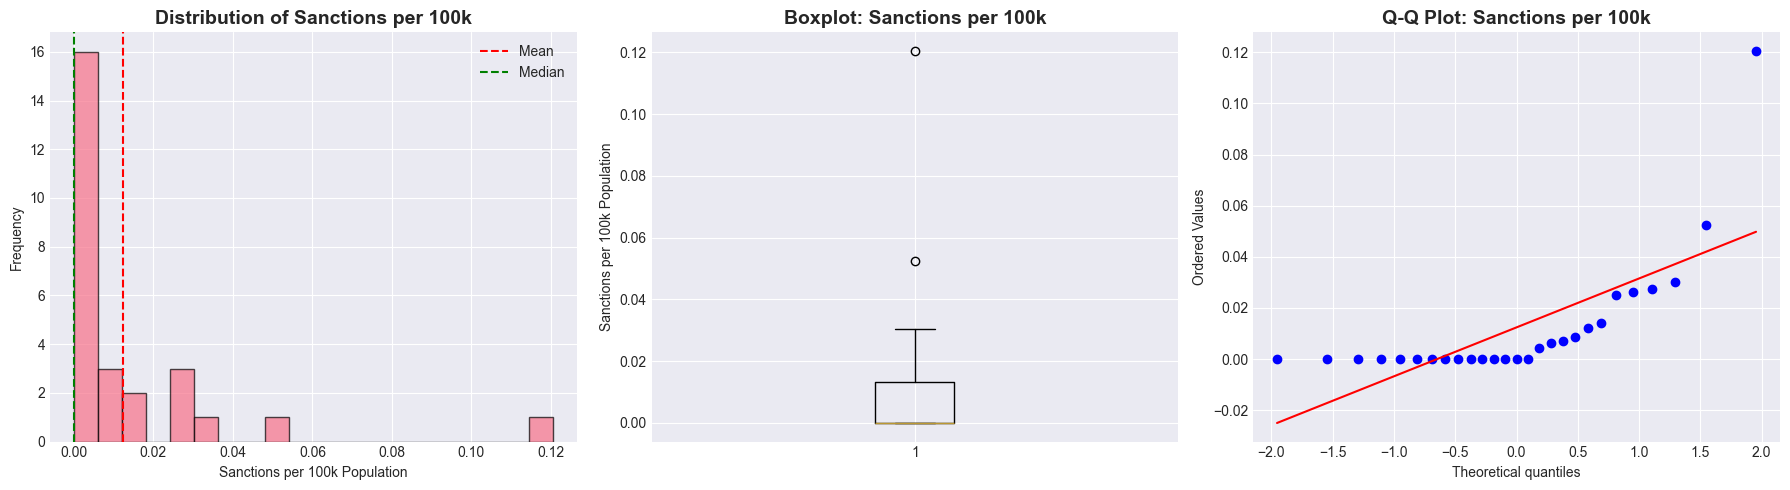

Skewness: 3.364
Kurtosis: 13.133


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_analysis['sanctions_per_100k'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Sanctions per 100k', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sanctions per 100k Population')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_analysis['sanctions_per_100k'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df_analysis['sanctions_per_100k'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

axes[1].boxplot(df_analysis['sanctions_per_100k'])
axes[1].set_title('Boxplot: Sanctions per 100k', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sanctions per 100k Population')

from scipy import stats
stats.probplot(df_analysis['sanctions_per_100k'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot: Sanctions per 100k', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Skewness: {df_analysis['sanctions_per_100k'].skew():.3f}")
print(f"Kurtosis: {df_analysis['sanctions_per_100k'].kurtosis():.3f}")

### 5.2 Socioeconomic Indicators

**Note on Log Transformation:** Population data is typically highly right-skewed — a few states have extremely large populations while most have much smaller values. The logarithmic transformation (log_population) addresses this by:
1. **Normalizing the distribution** — making it more symmetric for valid statistical analysis
2. **Reducing the influence of extreme values** — preventing large populations from disproportionately affecting correlations and regressions
3. **Enabling percentage-based interpretation** — in regression models, changes represent proportional effects

The histograms below compare the raw population distribution (skewed) with the log-transformed version (more normal).

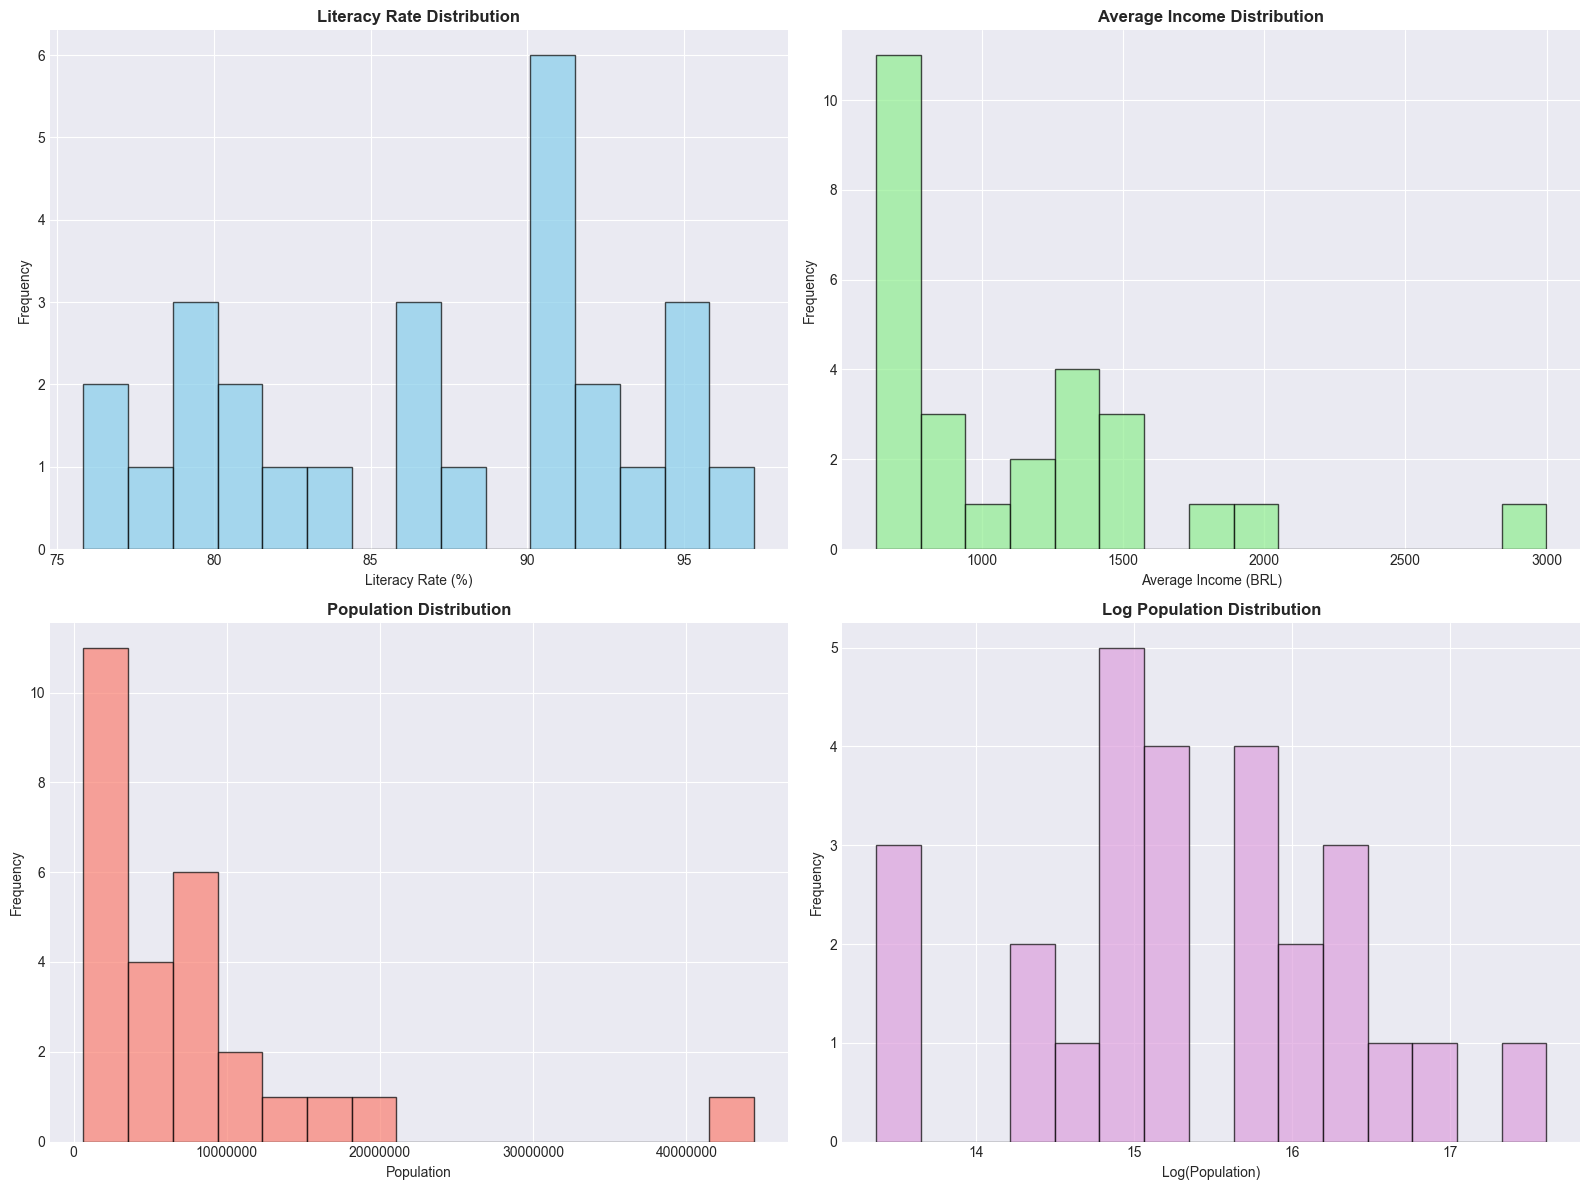

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(df_analysis['avg_literacy_rate'], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Literacy Rate Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Literacy Rate (%)')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df_analysis['avg_income'], bins=15, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].set_title('Average Income Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Average Income (BRL)')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(df_analysis['population'], bins=15, edgecolor='black', alpha=0.7, color='salmon')
axes[1, 0].set_title('Population Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Population')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(df_analysis['log_population'], bins=15, edgecolor='black', alpha=0.7, color='plum')
axes[1, 1].set_title('Log Population Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Log(Population)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Regional Analysis

In [51]:
regional_summary = df_analysis.groupby('region_name').agg({
    'state_code': 'count',
    'population': 'sum',
    'n_sanctions': 'sum',
    'sanctions_per_100k': 'mean',
    'avg_literacy_rate': 'mean',
    'avg_income': 'mean'
}).round(2)

regional_summary.columns = ['N States', 'Total Population', 'Total Sanctions', 
                            'Avg Sanctions/100k', 'Avg Literacy %', 'Avg Income (BRL)']

regional_summary

,N States,Total Population,Total Sanctions,Avg Sanctions/100k,Avg Literacy %,Avg Income (BRL)
region_name,,,,,,
Centro-Oeste,4,16289538,2,0.01,92.82,1826.63
Nordeste,9,54658515,3,0.01,79.18,755.31
Norte,7,17354884,2,0.02,87.68,849.37
Sudeste,4,84840113,4,0.01,92.74,1357.93
Sul,3,29937706,5,0.02,94.44,1754.85


In [52]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Sanctions per 100k by Region', 'Literacy Rate by Region',
                   'Average Income by Region', 'Total Sanctions by Region'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

regions = df_analysis.groupby('region_name').agg({
    'sanctions_per_100k': 'mean',
    'avg_literacy_rate': 'mean',
    'avg_income': 'mean',
    'n_sanctions': 'sum'
}).reset_index()

fig.add_trace(go.Bar(x=regions['region_name'], y=regions['sanctions_per_100k'], 
                     name='Sanctions/100k', marker_color='indianred'), row=1, col=1)
fig.add_trace(go.Bar(x=regions['region_name'], y=regions['avg_literacy_rate'], 
                     name='Literacy %', marker_color='lightseagreen'), row=1, col=2)
fig.add_trace(go.Bar(x=regions['region_name'], y=regions['avg_income'], 
                     name='Income', marker_color='lightsalmon'), row=2, col=1)
fig.add_trace(go.Bar(x=regions['region_name'], y=regions['n_sanctions'], 
                     name='Total Sanctions', marker_color='mediumpurple'), row=2, col=2)

fig.update_layout(height=800, showlegend=False, title_text="Regional Comparison Dashboard")
fig.show()

## 7. State-Level Analysis

In [53]:
top_10_sanctions = df_analysis.nlargest(10, 'sanctions_per_100k')[['state_name', 'sanctions_per_100k', 'n_sanctions']]
bottom_10_sanctions = df_analysis.nsmallest(10, 'sanctions_per_100k')[['state_name', 'sanctions_per_100k', 'n_sanctions']]

print("TOP 10 STATES - Highest Sanctions per 100k")
print("=" * 60)
print(top_10_sanctions.to_string(index=False))

print("\n\nBOTTOM 10 STATES - Lowest Sanctions per 100k")
print("=" * 60)
print(bottom_10_sanctions.to_string(index=False))

TOP 10 STATES - Highest Sanctions per 100k
         state_name  sanctions_per_100k  n_sanctions
               Acre                0.12            1
     Santa Catarina                0.05            4
Rio Grande do Norte                0.03            1
        Mato Grosso                0.03            1
     Espírito Santo                0.03            1
            Paraíba                0.03            1
              Goiás                0.01            1
               Pará                0.01            1
             Paraná                0.01            1
              Bahia                0.01            1


BOTTOM 10 STATES - Lowest Sanctions per 100k
state_name  sanctions_per_100k  n_sanctions
  Rondônia                0.00            0
  Amazonas                0.00            0
   Roraima                0.00            0
     Amapá                0.00            0
 Tocantins                0.00            0
  Maranhão                0.00            0
     Piauí         

In [54]:
fig = px.bar(df_analysis.sort_values('sanctions_per_100k', ascending=False),
             x='state_code', y='sanctions_per_100k',
             color='region_name',
             title='Sanctions per 100k Population by State',
             labels={'sanctions_per_100k': 'Sanctions per 100k', 'state_code': 'State'},
             height=500)
fig.show()

## 8. Sanctions Registry Analysis

In [55]:
if df_sanctions is not None:
    print("Sanctions by Registry Type:")
    print("=" * 60)
    display(df_sanctions[['registry_type', 'total_sanctions', 'sanctions_pf', 'sanctions_pj', 'pj_ratio_pct']])
    
    fig = px.pie(df_sanctions, values='total_sanctions', names='registry_type',
                 title='Sanctions Distribution by Registry Type')
    fig.show()

Sanctions by Registry Type:


,registry_type,total_sanctions,sanctions_pf,sanctions_pj,pj_ratio_pct
0,CEAF,4148,0,0,0.00
1,CEIS,15,0,0,0.00
2,CEPIM,15,0,0,0.00
3,CNEP,2,0,0,0.00


## 9. Correlation Heatmap (Preview)

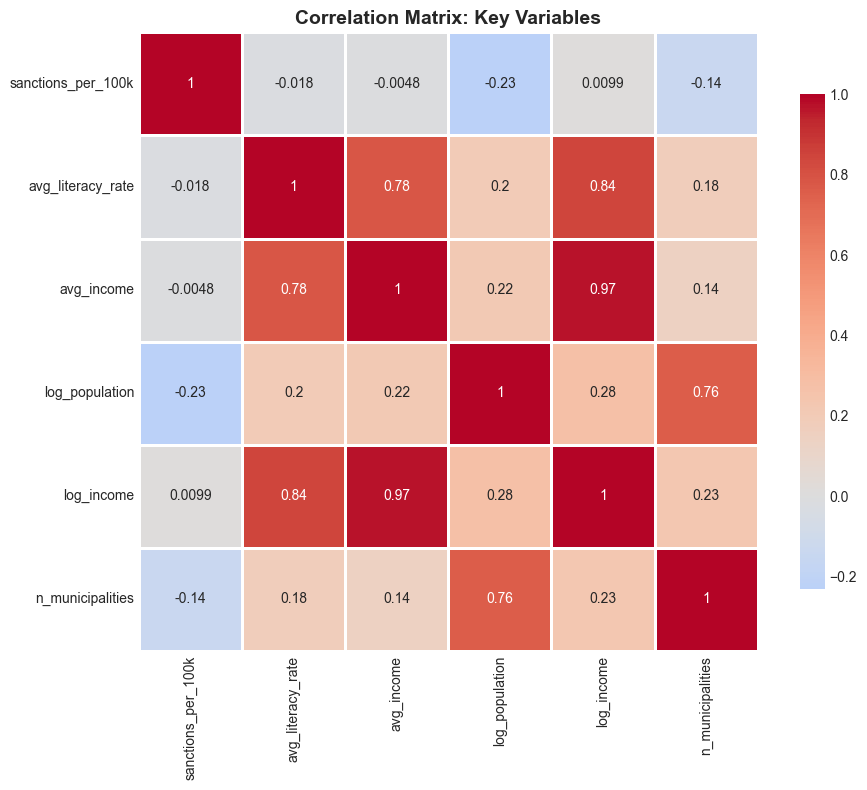

In [56]:
corr_cols = ['sanctions_per_100k', 'avg_literacy_rate', 'avg_income', 
             'log_population', 'log_income', 'n_municipalities']

corr_matrix = df_analysis[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Key Findings Summary

**Document your initial observations here:**

1. **Data Quality:**
   - Missing values?
   - Outliers?
   - Data distribution characteristics?

2. **Regional Patterns:**
   - Which regions have highest/lowest sanctions rates?
   - Regional differences in socioeconomic indicators?

3. **Initial Correlations:**
   - Relationship between sanctions and literacy?
   - Relationship between sanctions and income?
   - Population effects?

4. **Next Steps:**
   - Statistical tests needed?
   - Variables to transform?
   - Hypotheses to test?